In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import time
import statsmodels.api as sm

In [3]:
raw_data = fetch_california_housing()
house_data = pd.DataFrame(raw_data.data, columns=raw_data.feature_names)
house_data['target'] = raw_data.target
house_data
#house_data = pd.concat(

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [4]:
feat, targ = raw_data.data, raw_data.target
feat_train, feat_test, targ_train, targ_test = train_test_split(feat, targ, test_size=0.2, random_state=38)

In [5]:
obs, feats = feat.shape
print('Number of Observations: ' + str(obs))
print('Number of Features: ' + str(feats))

Number of Observations: 20640
Number of Features: 8


In [6]:
ests = 100
rforest = RandomForestRegressor(n_estimators=ests,random_state=36)
xgboost = XGBRegressor(n_estimators=ests,random_state=36)

In [7]:
start_f = time.time()
rforest.fit(feat_train,targ_train)
stop_f = time.time()
targ_pred_f = rforest.predict(feat_test)
end_f =time.time()
delta_f = stop_f - start_f
delta_f2 = end_f - stop_f

start_x = time.time()
xgboost.fit(feat_train,targ_train)
stop_x = time.time()
targ_pred_x = xgboost.predict(feat_test)
end_x = time.time()
delta_x = stop_x - start_x
delta_x2 = end_x - stop_x

print("Time taken to train and test using Random Forest: {:.3f}, {:.3f}".format(delta_f, delta_f2))
print("Time taken to train and test using XGBoost: {:.3f}, {:.3f}".format(delta_x, delta_x2))

Time taken to train and test using Random Forest: 20.270, 0.300
Time taken to train and test using XGBoost: 1.858, 0.063


In [8]:
mse_f = mean_squared_error(targ_test, targ_pred_f)
mse_x = mean_squared_error(targ_test, targ_pred_x)
r2_f = r2_score(targ_test, targ_pred_f)
r2_x = r2_score(targ_test, targ_pred_x)

print(f'Random Forest:  MSE = {mse_f:.4f}, R^2 Score = {r2_f:.4f}')
print(f'      XGBoost:  MSE = {mse_x:.4f}, R^2 Score = {r2_x:.4f}')

Random Forest:  MSE = 0.2651, R^2 Score = 0.8044
      XGBoost:  MSE = 0.2247, R^2 Score = 0.8342


In [9]:
std = np.std(targ_test)

In [10]:
from sklearn.metrics import accuracy_score
#print(accuracy_score(targ_pred_x, targ_test))

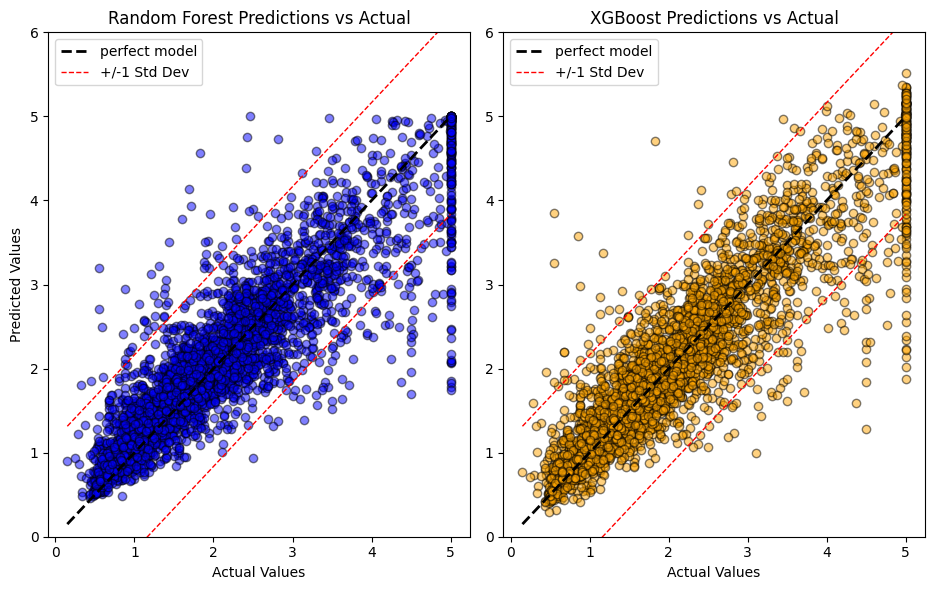

In [11]:
plt.figure(figsize=(14, 6))

# Random Forest plot
plt.subplot(1, 3, 1)
plt.scatter(targ_test, targ_pred_f, alpha=0.5, color="blue",ec='k')
plt.plot([targ_test.min(), targ_test.max()], [targ_test.min(), targ_test.max()], 'k--', lw=2,label="perfect model")
plt.plot([targ_test.min(), targ_test.max()], [targ_test.min() + std, targ_test.max() + std], 'r--', lw=1, label="+/-1 Std Dev")
plt.plot([targ_test.min(), targ_test.max()], [targ_test.min() - std, targ_test.max() - std], 'r--', lw=1, )
plt.ylim(0,6)
plt.title("Random Forest Predictions vs Actual")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.legend()


# XGBoost plot
plt.subplot(1, 3, 2)
plt.scatter(targ_test, targ_pred_x, alpha=0.5, color="orange",ec='k')
plt.plot([targ_test.min(), targ_test.max()], [targ_test.min(), targ_test.max()], 'k--', lw=2,label="perfect model")
plt.plot([targ_test.min(), targ_test.max()], [targ_test.min() + std, targ_test.max() + std], 'r--', lw=1, label="+/-1 Std Dev")
plt.plot([targ_test.min(), targ_test.max()], [targ_test.min() - std, targ_test.max() - std], 'r--', lw=1, )
plt.ylim(0,6)
plt.title("XGBoost Predictions vs Actual")
plt.xlabel("Actual Values")
plt.legend()
plt.tight_layout()
plt.show()